In [ ]:
from pathlib import Path
from math import log, sqrt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Locate files
# ------------------------------------------------------------
BASE_DIRS = [Path("."), Path("_experiment_cache")]

def find_one(pattern: str) -> Path:
    matches = []
    for base_dir in BASE_DIRS:
        matches.extend(sorted(base_dir.glob(pattern)))
    if not matches:
        raise FileNotFoundError(f"Could not find file matching pattern: {pattern}")
    return matches[0]


exact_path = find_one("*exact_cdf*.npz")
mc_path = find_one("*monte_carlo*.npz")

exact = np.load(exact_path, allow_pickle=True)
mc = np.load(mc_path, allow_pickle=True)

print(f"Loaded exact results from: {exact_path}")
print(f"Loaded Monte Carlo results from: {mc_path}")


# ------------------------------------------------------------
# Extract exact results
# ------------------------------------------------------------
support = exact["support"].astype(int)
exact_cdf = exact["exact_cdf"].astype(float)
exact_pmf = exact["exact_pmf"].astype(float)

max_t = int(exact["max_t"])
exact_tail_mass = float(exact["exact_tail_mass"])
exact_runtime_total_seconds = float(exact["exact_runtime_total_seconds"])

if "exact_cdf_runtime_by_t_seconds" in exact.files:
    exact_runtime_by_t_seconds = exact["exact_cdf_runtime_by_t_seconds"].astype(float)
else:
    exact_runtime_by_t_seconds = None


# ------------------------------------------------------------
# Extract Monte Carlo results
# ------------------------------------------------------------
completion_samples = mc["completion_samples"].astype(np.int64)
sample_count = int(mc["sample_count"])
mc_runtime_total_seconds = float(mc["monte_carlo_runtime_total_seconds"])
rng_seed = int(mc["rng_seed"])


# ------------------------------------------------------------
# Empirical CDF and PMF on exact support grid
# ------------------------------------------------------------
mc_cdf = np.array([
    np.mean(completion_samples <= t)
    for t in support
])

max_observed = int(completion_samples.max())
mc_counts = np.bincount(completion_samples, minlength=max(max_observed + 1, max_t + 1))

mc_pmf = np.array([
    mc_counts[t] / sample_count if t < len(mc_counts) else 0.0
    for t in support
])


# ------------------------------------------------------------
# CDF error diagnostics
# ------------------------------------------------------------
cdf_error = mc_cdf - exact_cdf
abs_cdf_error = np.abs(cdf_error)

ks_distance = float(abs_cdf_error.max())
ks_t = int(support[abs_cdf_error.argmax()])

cdf_mae = float(abs_cdf_error.mean())
cdf_rmse = float(np.sqrt(np.mean(cdf_error**2)))

alpha = 0.05
dkw_epsilon = sqrt(log(2 / alpha) / (2 * sample_count))

pointwise_se = np.sqrt(exact_cdf * (1 - exact_cdf) / sample_count)
pointwise_95_half_width = 1.96 * pointwise_se

mc_tail_mass = float(np.mean(completion_samples > max_t))


# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------
OUT_DIR = Path("mc_cdf_validation_outputs_poisson_exp")
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, stem: str) -> None:
    fig.savefig(FIG_DIR / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{stem}.png", dpi=300, bbox_inches="tight")


print(f"Output folder: {OUT_DIR.resolve()}")

Loaded exact results from: _experiment_cache\Building_Garage_sig_1779049297916769800_exact_cdf_growing_support_longdouble_v2.npz
Loaded Monte Carlo results from: _experiment_cache\Building_Garage_sig_1779049297916769800_samples_10000000_seed_2026_monte_carlo.npz
Output folder: C:\Users\johan\OneDrive\Skrivbord\SPM\Time only poisson experiment\notebooks\mc_cdf_validation_outputs


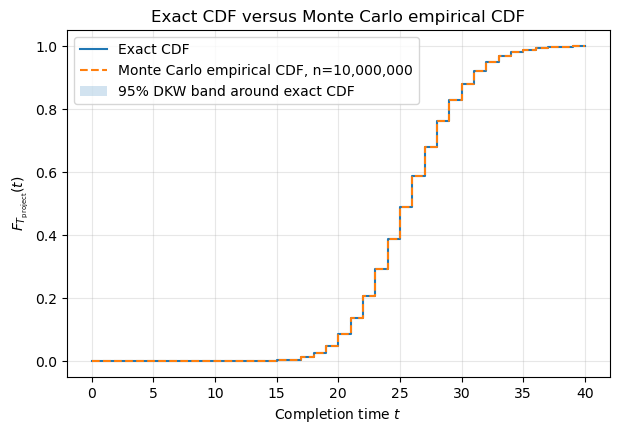

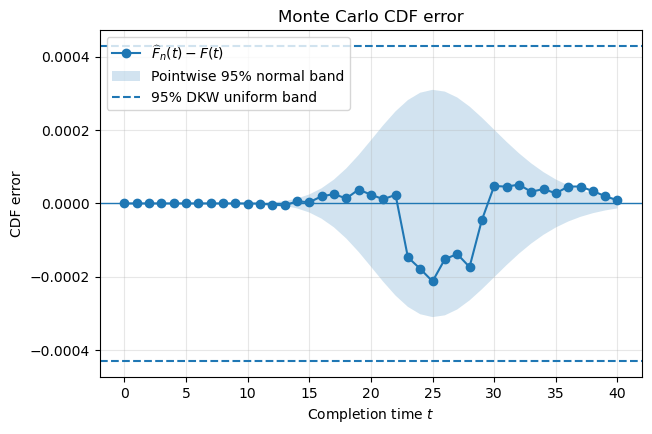

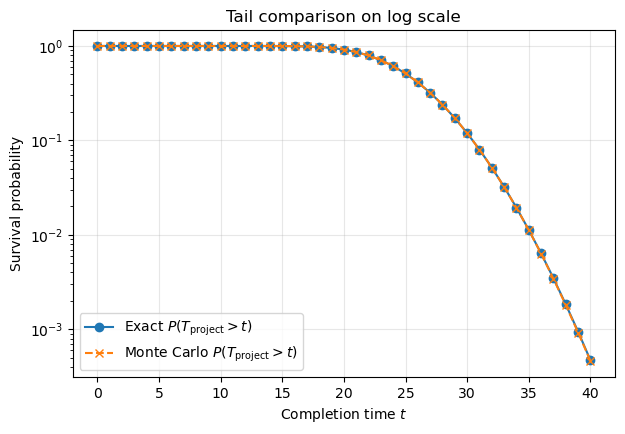

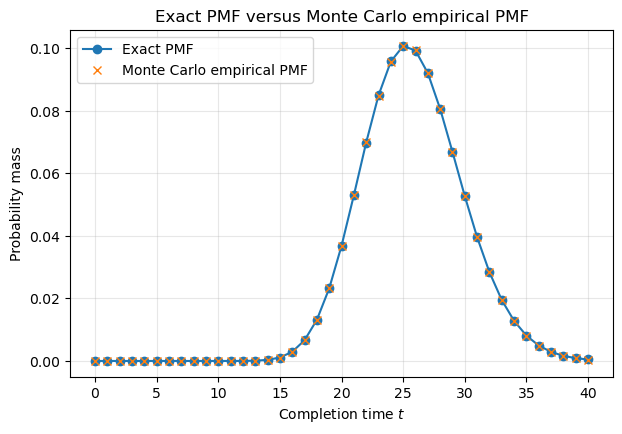

In [2]:
# ------------------------------------------------------------
# Plot 1: Exact CDF versus Monte Carlo empirical CDF
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))

lower_dkw = np.clip(exact_cdf - dkw_epsilon, 0, 1)
upper_dkw = np.clip(exact_cdf + dkw_epsilon, 0, 1)

ax.step(support, exact_cdf, where="post", label="Exact CDF")
ax.step(
    support,
    mc_cdf,
    where="post",
    linestyle="--",
    label=f"Monte Carlo empirical CDF, n={sample_count:,}",
)
ax.fill_between(
    support,
    lower_dkw,
    upper_dkw,
    step="post",
    alpha=0.2,
    label="95% DKW band around exact CDF",
)

ax.set_xlabel(r"Completion time $t$")
ax.set_ylabel(r"$F_{T_{\mathrm{project}}}(t)$")
ax.set_title("Exact CDF versus Monte Carlo empirical CDF")
ax.grid(True, alpha=0.3)
ax.legend()

save_figure(fig, "cdf_exact_vs_monte_carlo")
plt.show()


# ------------------------------------------------------------
# Plot 2: CDF error with pointwise and uniform reference bands
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(support, cdf_error, marker="o", label=r"$\widehat F_n(t)-F(t)$")

ax.fill_between(
    support,
    -pointwise_95_half_width,
    pointwise_95_half_width,
    alpha=0.2,
    label="Pointwise 95% normal band",
)

ax.axhline(dkw_epsilon, linestyle="--", label="95% DKW uniform band")
ax.axhline(-dkw_epsilon, linestyle="--")
ax.axhline(0, linewidth=1)

ax.set_xlabel(r"Completion time $t$")
ax.set_ylabel("CDF error")
ax.set_title("Monte Carlo CDF error")
ax.grid(True, alpha=0.3)
ax.legend()

save_figure(fig, "cdf_error_with_confidence_bands")
plt.show()


# ------------------------------------------------------------
# Plot 3: Survival tail comparison
# ------------------------------------------------------------
exact_survival = 1 - exact_cdf
mc_survival = 1 - mc_cdf

tail_mask = (exact_survival > 0) | (mc_survival > 0)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.semilogy(
    support[tail_mask],
    exact_survival[tail_mask],
    marker="o",
    label=r"Exact $P(T_{\mathrm{project}}>t)$",
)
ax.semilogy(
    support[tail_mask],
    mc_survival[tail_mask],
    marker="x",
    linestyle="--",
    label=r"Monte Carlo $P(T_{\mathrm{project}}>t)$",
)

ax.set_xlabel(r"Completion time $t$")
ax.set_ylabel(r"Survival probability")
ax.set_title("Tail comparison on log scale")
ax.grid(True, alpha=0.3)
ax.legend()

save_figure(fig, "survival_tail_exact_vs_monte_carlo")
plt.show()


# ------------------------------------------------------------
# Plot 4: Exact PMF versus Monte Carlo empirical PMF
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(support, exact_pmf, marker="o", label="Exact PMF")
ax.plot(
    support,
    mc_pmf,
    marker="x",
    linestyle="None",
    label="Monte Carlo empirical PMF",
)

ax.set_xlabel(r"Completion time $t$")
ax.set_ylabel(r"Probability mass")
ax.set_title("Exact PMF versus Monte Carlo empirical PMF")
ax.grid(True, alpha=0.3)
ax.legend()

save_figure(fig, "pmf_exact_vs_monte_carlo")
plt.show()